In [1]:
import zipfile

In [2]:
path=zipfile.ZipFile("/content/Keyboard-Mouse-Laptop detection.v1i.yolov11.zip")

In [3]:
path.extractall("Keyboard_mouse and Laptop Detection")

In [4]:
#First we Installing Ultralytics from which we can excess the yolo
!pip install Ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.8 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO

####Lets we are using yolov8n First

In [7]:
model_1n=YOLO("yolov8n.pt")

###Training Our Model

In [11]:
model_1n.train(data="/content/Keyboard_mouse and Laptop Detection/data.yaml",epochs=45)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Keyboard_mouse and Laptop Detection/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=45, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/train-3/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7badf63d3380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

#mAP Graph

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("runs/detect/train/results.csv")

plt.plot(results["epoch"], results["metrics/mAP50(B)"], label="mAP50")
plt.plot(results["epoch"], results["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP vs Epoch")
plt.legend()
plt.show()

In [12]:
model_1nb=YOLO("/content/runs/detect/train-4/weights/best.pt")

##Lets we evaluating our results

In [18]:
results_1nb = model_1nb.val(
    data="/content/Keyboard_mouse and Laptop Detection/data.yaml",
    split="test"
)

# Is mein model.val() trained model ki performance ko unseen images par check karta hai.

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 901.3±246.5 MB/s, size: 53.1 KB)
val: Scanning /content/Keyboard_mouse and Laptop Detection/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 6.0it/s 0.2s
                   all         10         24      0.614      0.747      0.722      0.456
              Keyboard          6         10      0.721        0.7      0.776      0.512
                 Mouse          6          6      0.659          1      0.893      0.642
                laptop          2          8      0.462      0.541      0.495      0.215
Speed: 0.4ms preprocess, 5.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/dete

In [19]:
results_1nb

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7badf61e87c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

#Our First Model result

In [21]:
print("Precision:", results_1nb.box.mp)
print("Recall:", results_1nb.box.mr)
print("mAP50:", results_1nb.box.map50)
print("mAP50-95:", results_1nb.box.map)

Precision: 0.61394287878628
Recall: 0.7468667218368662
mAP50: 0.7215013227513228
mAP50-95: 0.4562526235701004


In [23]:
import os
#Finding confusion matrix

print(os.listdir("runs/detect/val-5"))

['BoxR_curve.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'BoxP_curve.png', 'confusion_matrix.png', 'val_batch0_labels.jpg', 'val_batch0_pred.jpg', 'BoxF1_curve.png']


In [24]:
from IPython.display import Image,display

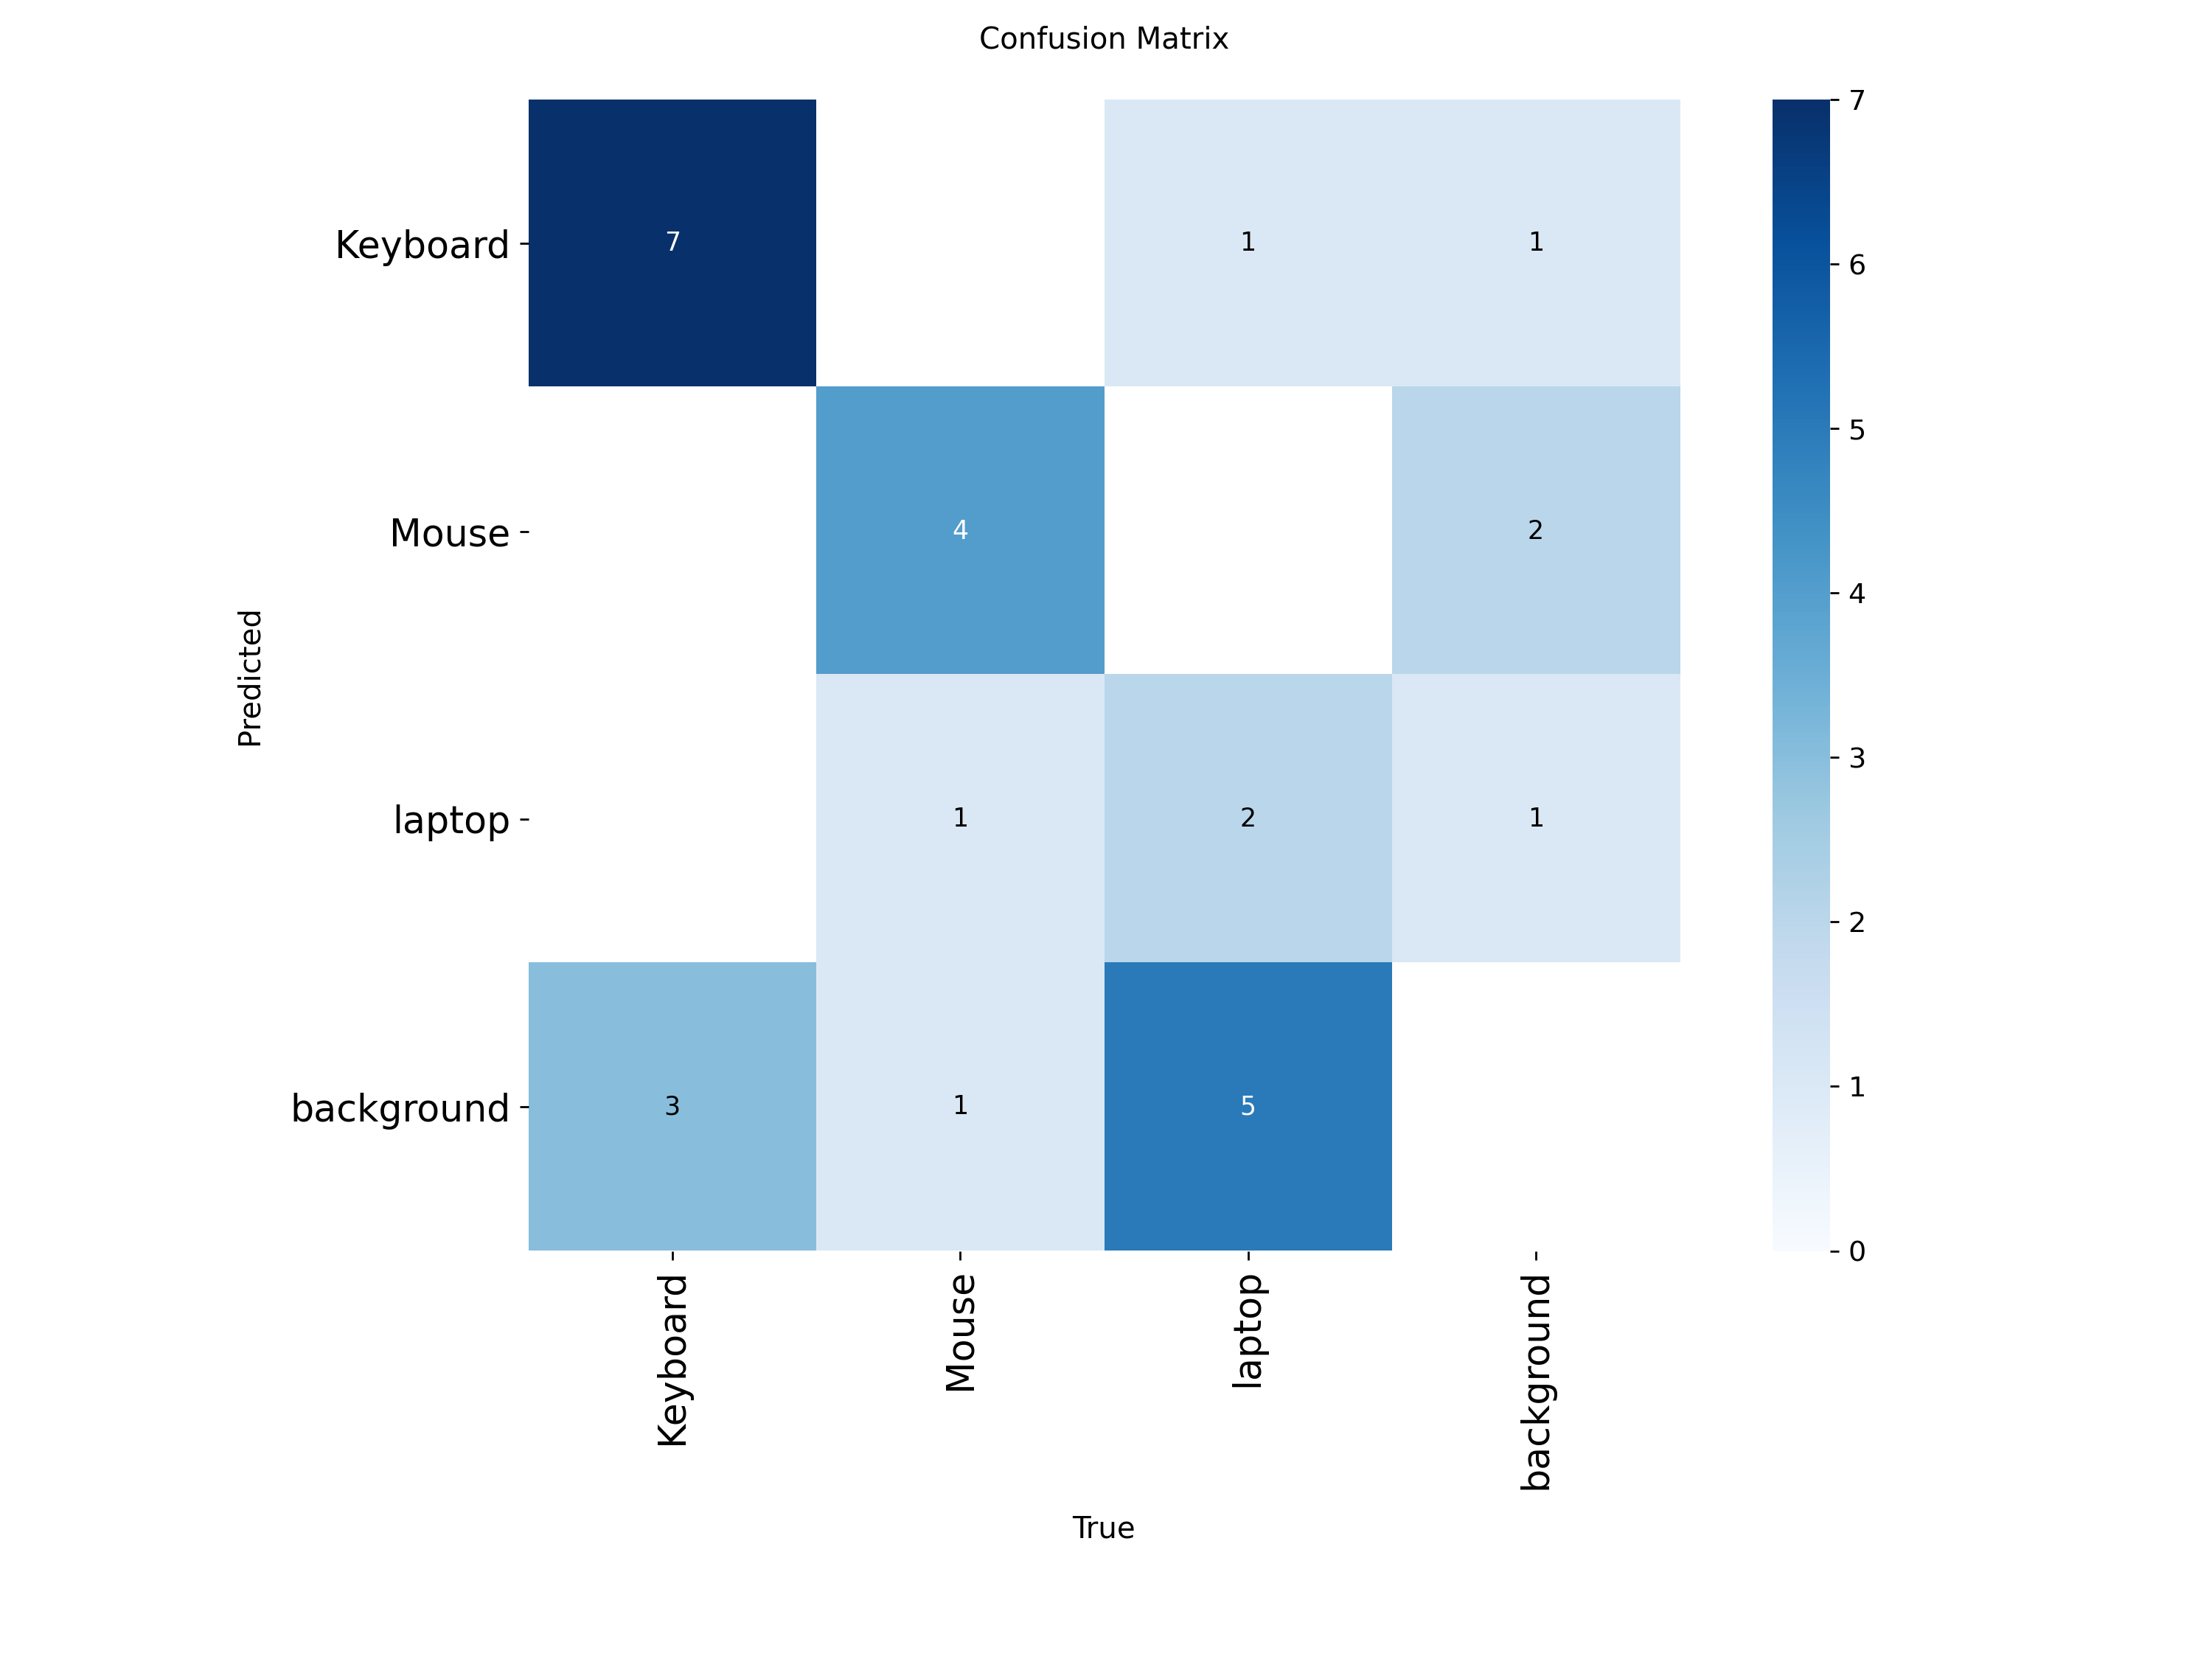

In [26]:
display(Image(filename="/content/runs/detect/val-5/confusion_matrix.png"))

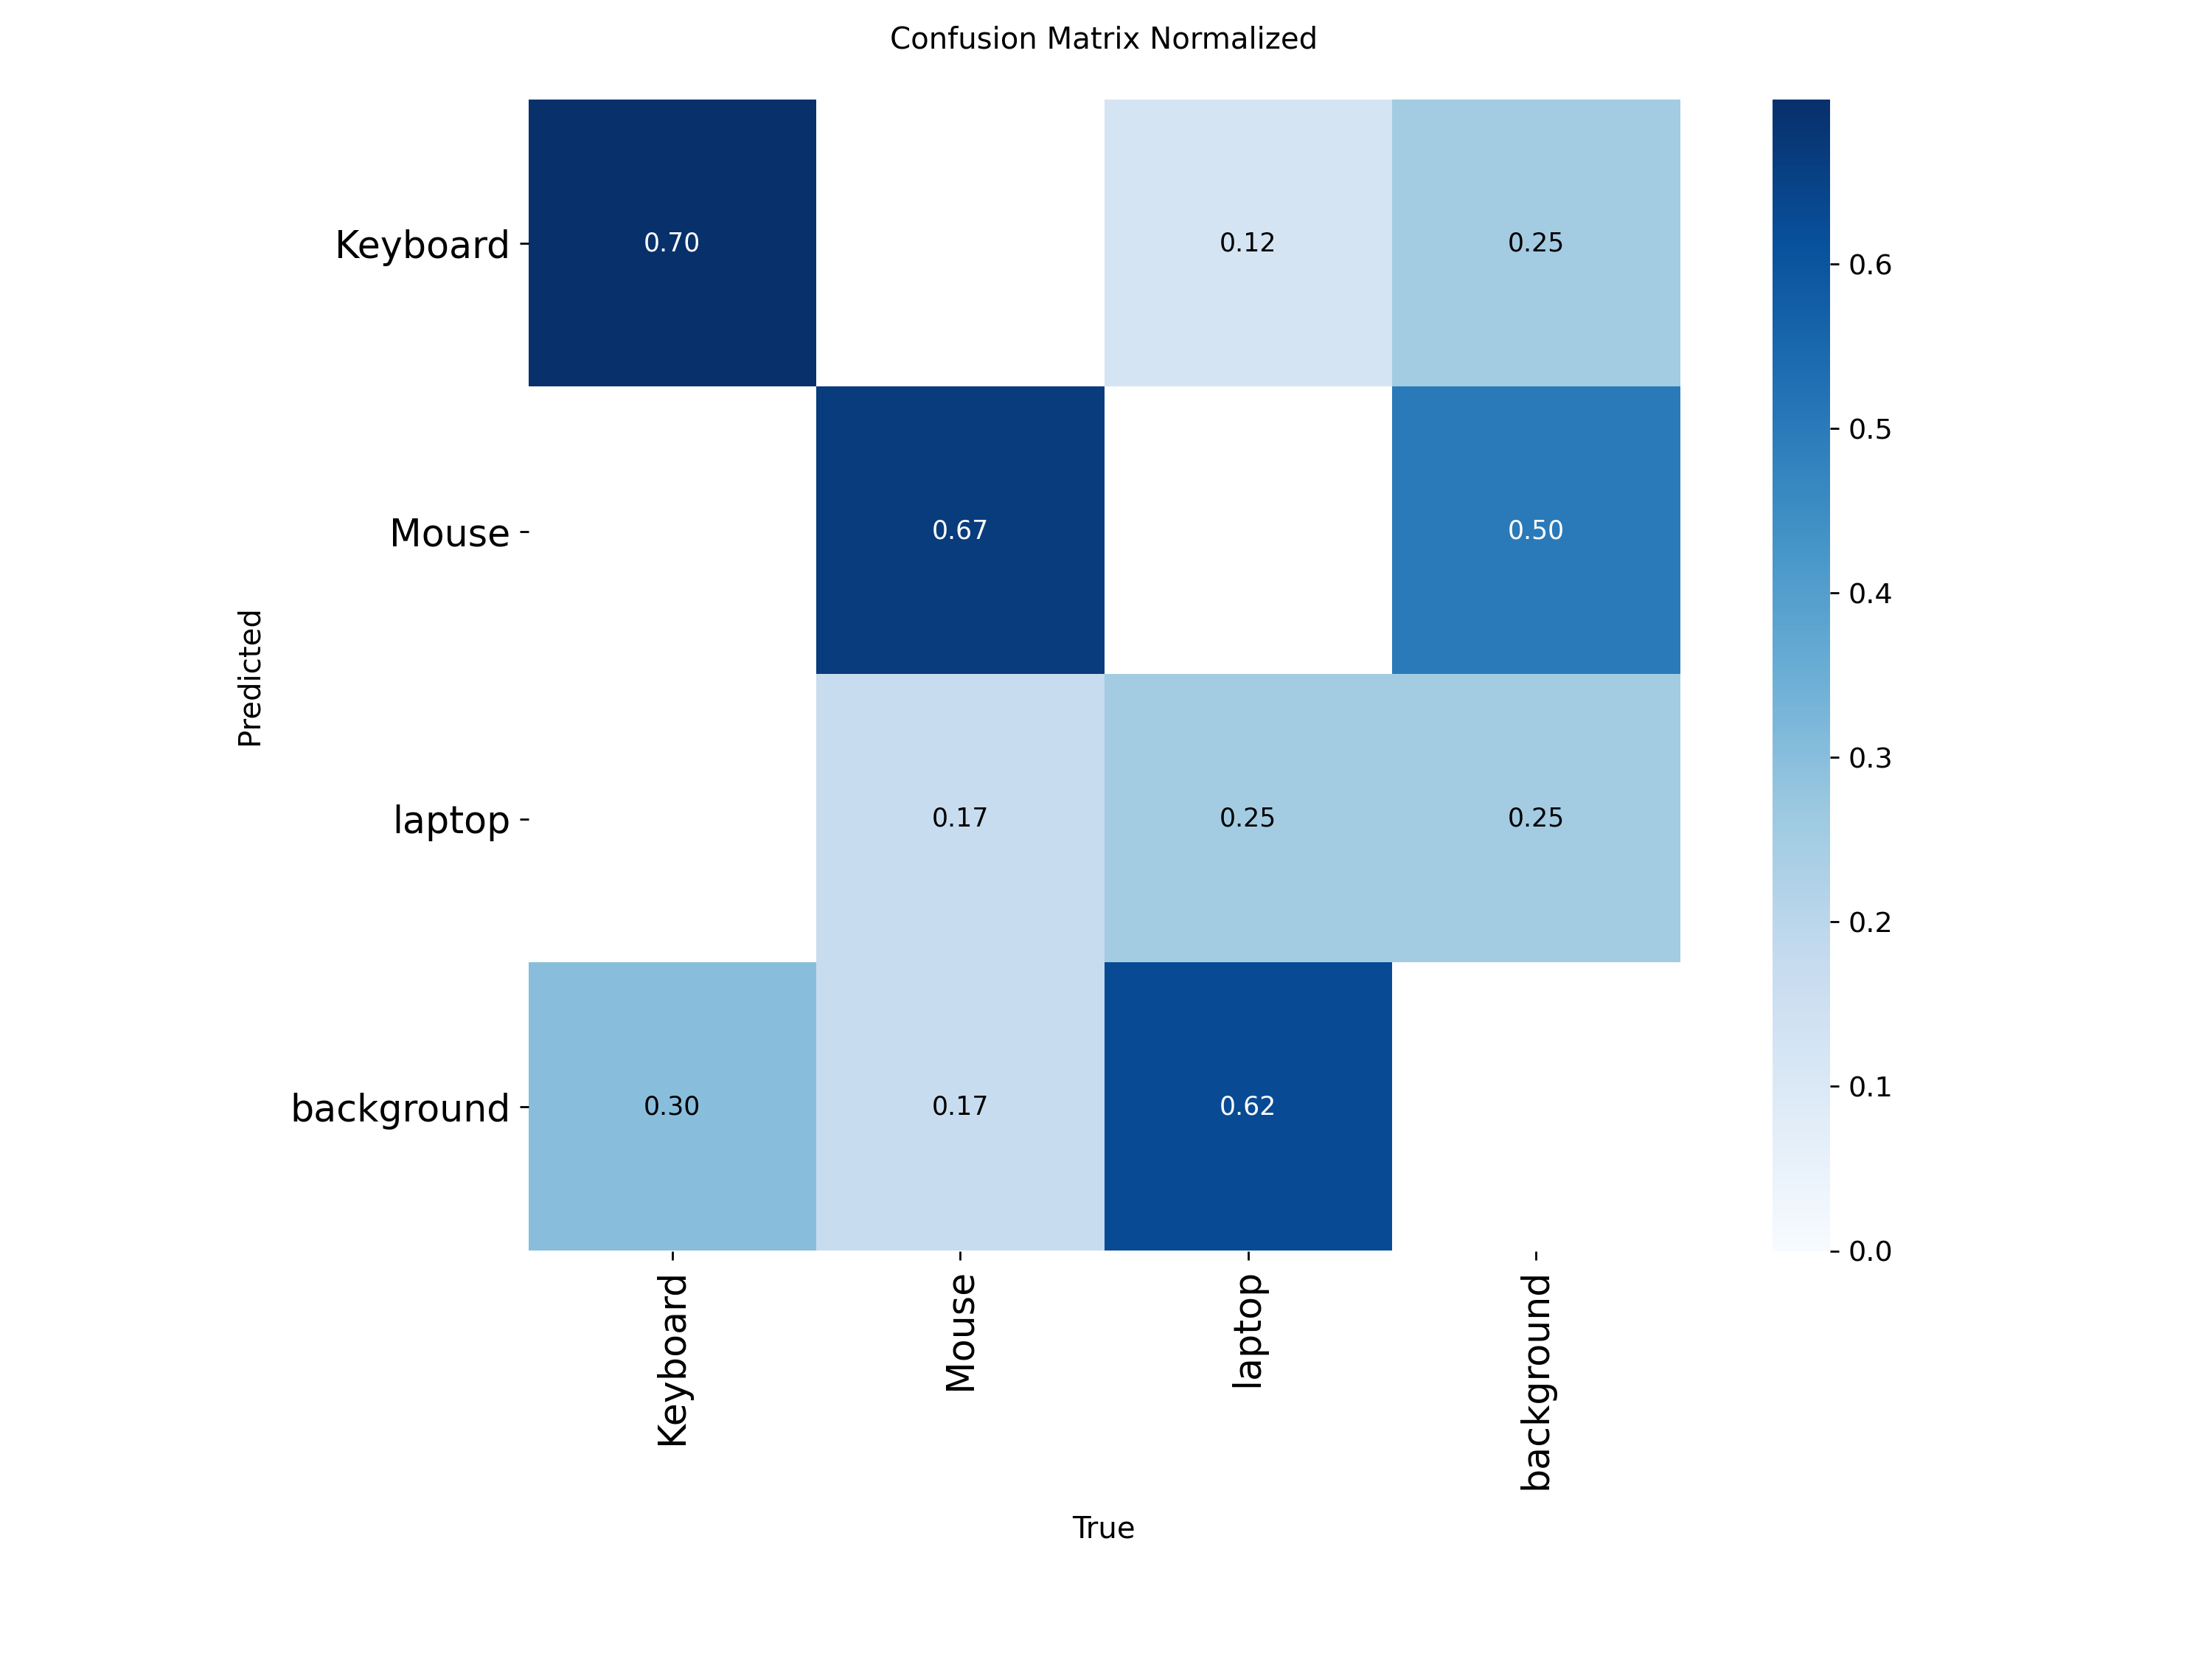

In [27]:
display(Image(filename="/content/runs/detect/val-5/confusion_matrix_normalized.png"))

In [35]:
pred1=model_1nb.predict(source="/content/Keyboard_mouse and Laptop Detection/test/images/pexels-bertellifotografia-7031695_jpg.rf.67f40d49cc775e00ebff33278e0d3174.jpg",conf=0.40)


image 1/1 /content/Keyboard_mouse and Laptop Detection/test/images/pexels-bertellifotografia-7031695_jpg.rf.67f40d49cc775e00ebff33278e0d3174.jpg: 640x640 1 Keyboard, 1 Mouse, 17.9ms
Speed: 2.6ms preprocess, 17.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


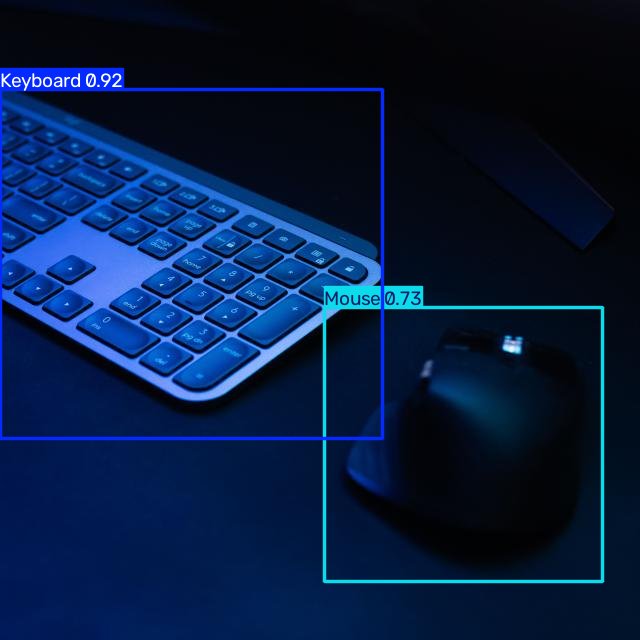

In [36]:
pred1[0].show()

In [37]:
pred2=model_1nb.predict(source="/content/Keyboard_mouse and Laptop Detection/test/images/pexels-rafael-quaty-37077235-14401665_jpg.rf.6902bc68d35513b501c75012345c9270.jpg",conf=0.40)


image 1/1 /content/Keyboard_mouse and Laptop Detection/test/images/pexels-rafael-quaty-37077235-14401665_jpg.rf.6902bc68d35513b501c75012345c9270.jpg: 640x640 1 Mouse, 7.3ms
Speed: 1.3ms preprocess, 7.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


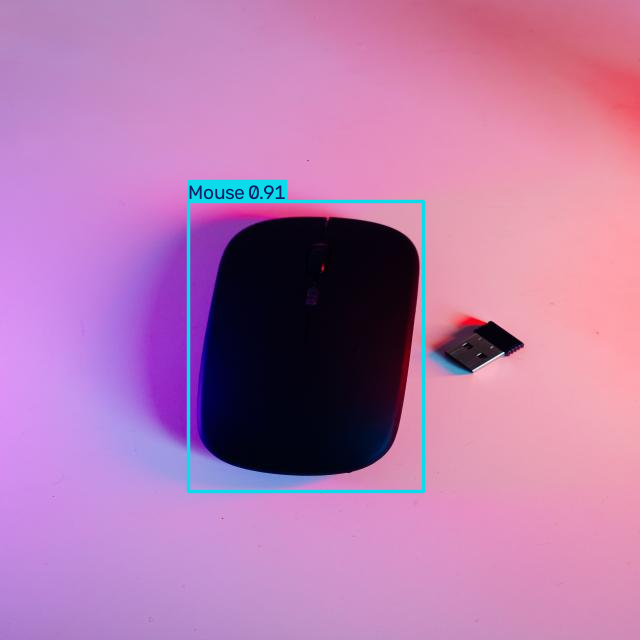

In [40]:
pred2[0].show()

In [41]:
pred3=model_1nb.predict(source="/content/Keyboard_mouse and Laptop Detection/test/images/pexels-zeleboba-26732223_jpg.rf.13717b6145159a2244a32e97cb3b1a6b.jpg",conf=0.40)


image 1/1 /content/Keyboard_mouse and Laptop Detection/test/images/pexels-zeleboba-26732223_jpg.rf.13717b6145159a2244a32e97cb3b1a6b.jpg: 640x640 1 Mouse, 7.5ms
Speed: 1.2ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


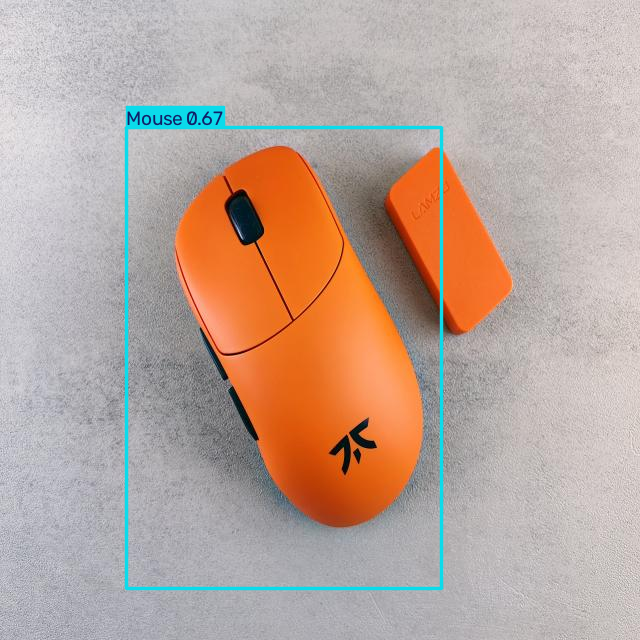

In [42]:
pred3[0].show()

##Making 2nd Model

In [43]:
model_1s=YOLO("yolov8s.pt")

##Training Model

In [44]:
model_1s.train(data="/content/Keyboard_mouse and Laptop Detection/data.yaml",epochs=40)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Keyboard_mouse and Laptop Detection/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=None, opset=No

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7badf6314830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

##mAP Graph

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("runs/detect/train/results.csv")

plt.plot(results["epoch"], results["metrics/mAP50(B)"], label="mAP50")
plt.plot(results["epoch"], results["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP vs Epoch")
plt.legend()
plt.show()

In [45]:
model_1sb=YOLO("/content/runs/detect/train-5/weights/best.pt")

#Evaluating Results

In [47]:
results_1sb = model_1sb.val(
    data="/content/Keyboard_mouse and Laptop Detection/data.yaml",
    split="test"
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1563.2±106.1 MB/s, size: 41.7 KB)
val: Scanning /content/Keyboard_mouse and Laptop Detection/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.8it/s 0.3s
                   all         10         24       0.83      0.574      0.702      0.393
              Keyboard          6         10      0.872        0.7      0.791       0.47
                 Mouse          6          6      0.881      0.667      0.817      0.554
                laptop          2          8      0.737      0.356      0.499      0.155
Speed: 0.4ms preprocess, 14.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/

In [48]:
print("Precision:", results_1sb.box.mp)
print("Recall:", results_1sb.box.mr)
print("mAP50:", results_1sb.box.map50)
print("mAP50-95:", results_1sb.box.map)

Precision: 0.8302685638999591
Recall: 0.5743047650028613
mAP50: 0.7024611257226039
mAP50-95: 0.3930450600152202


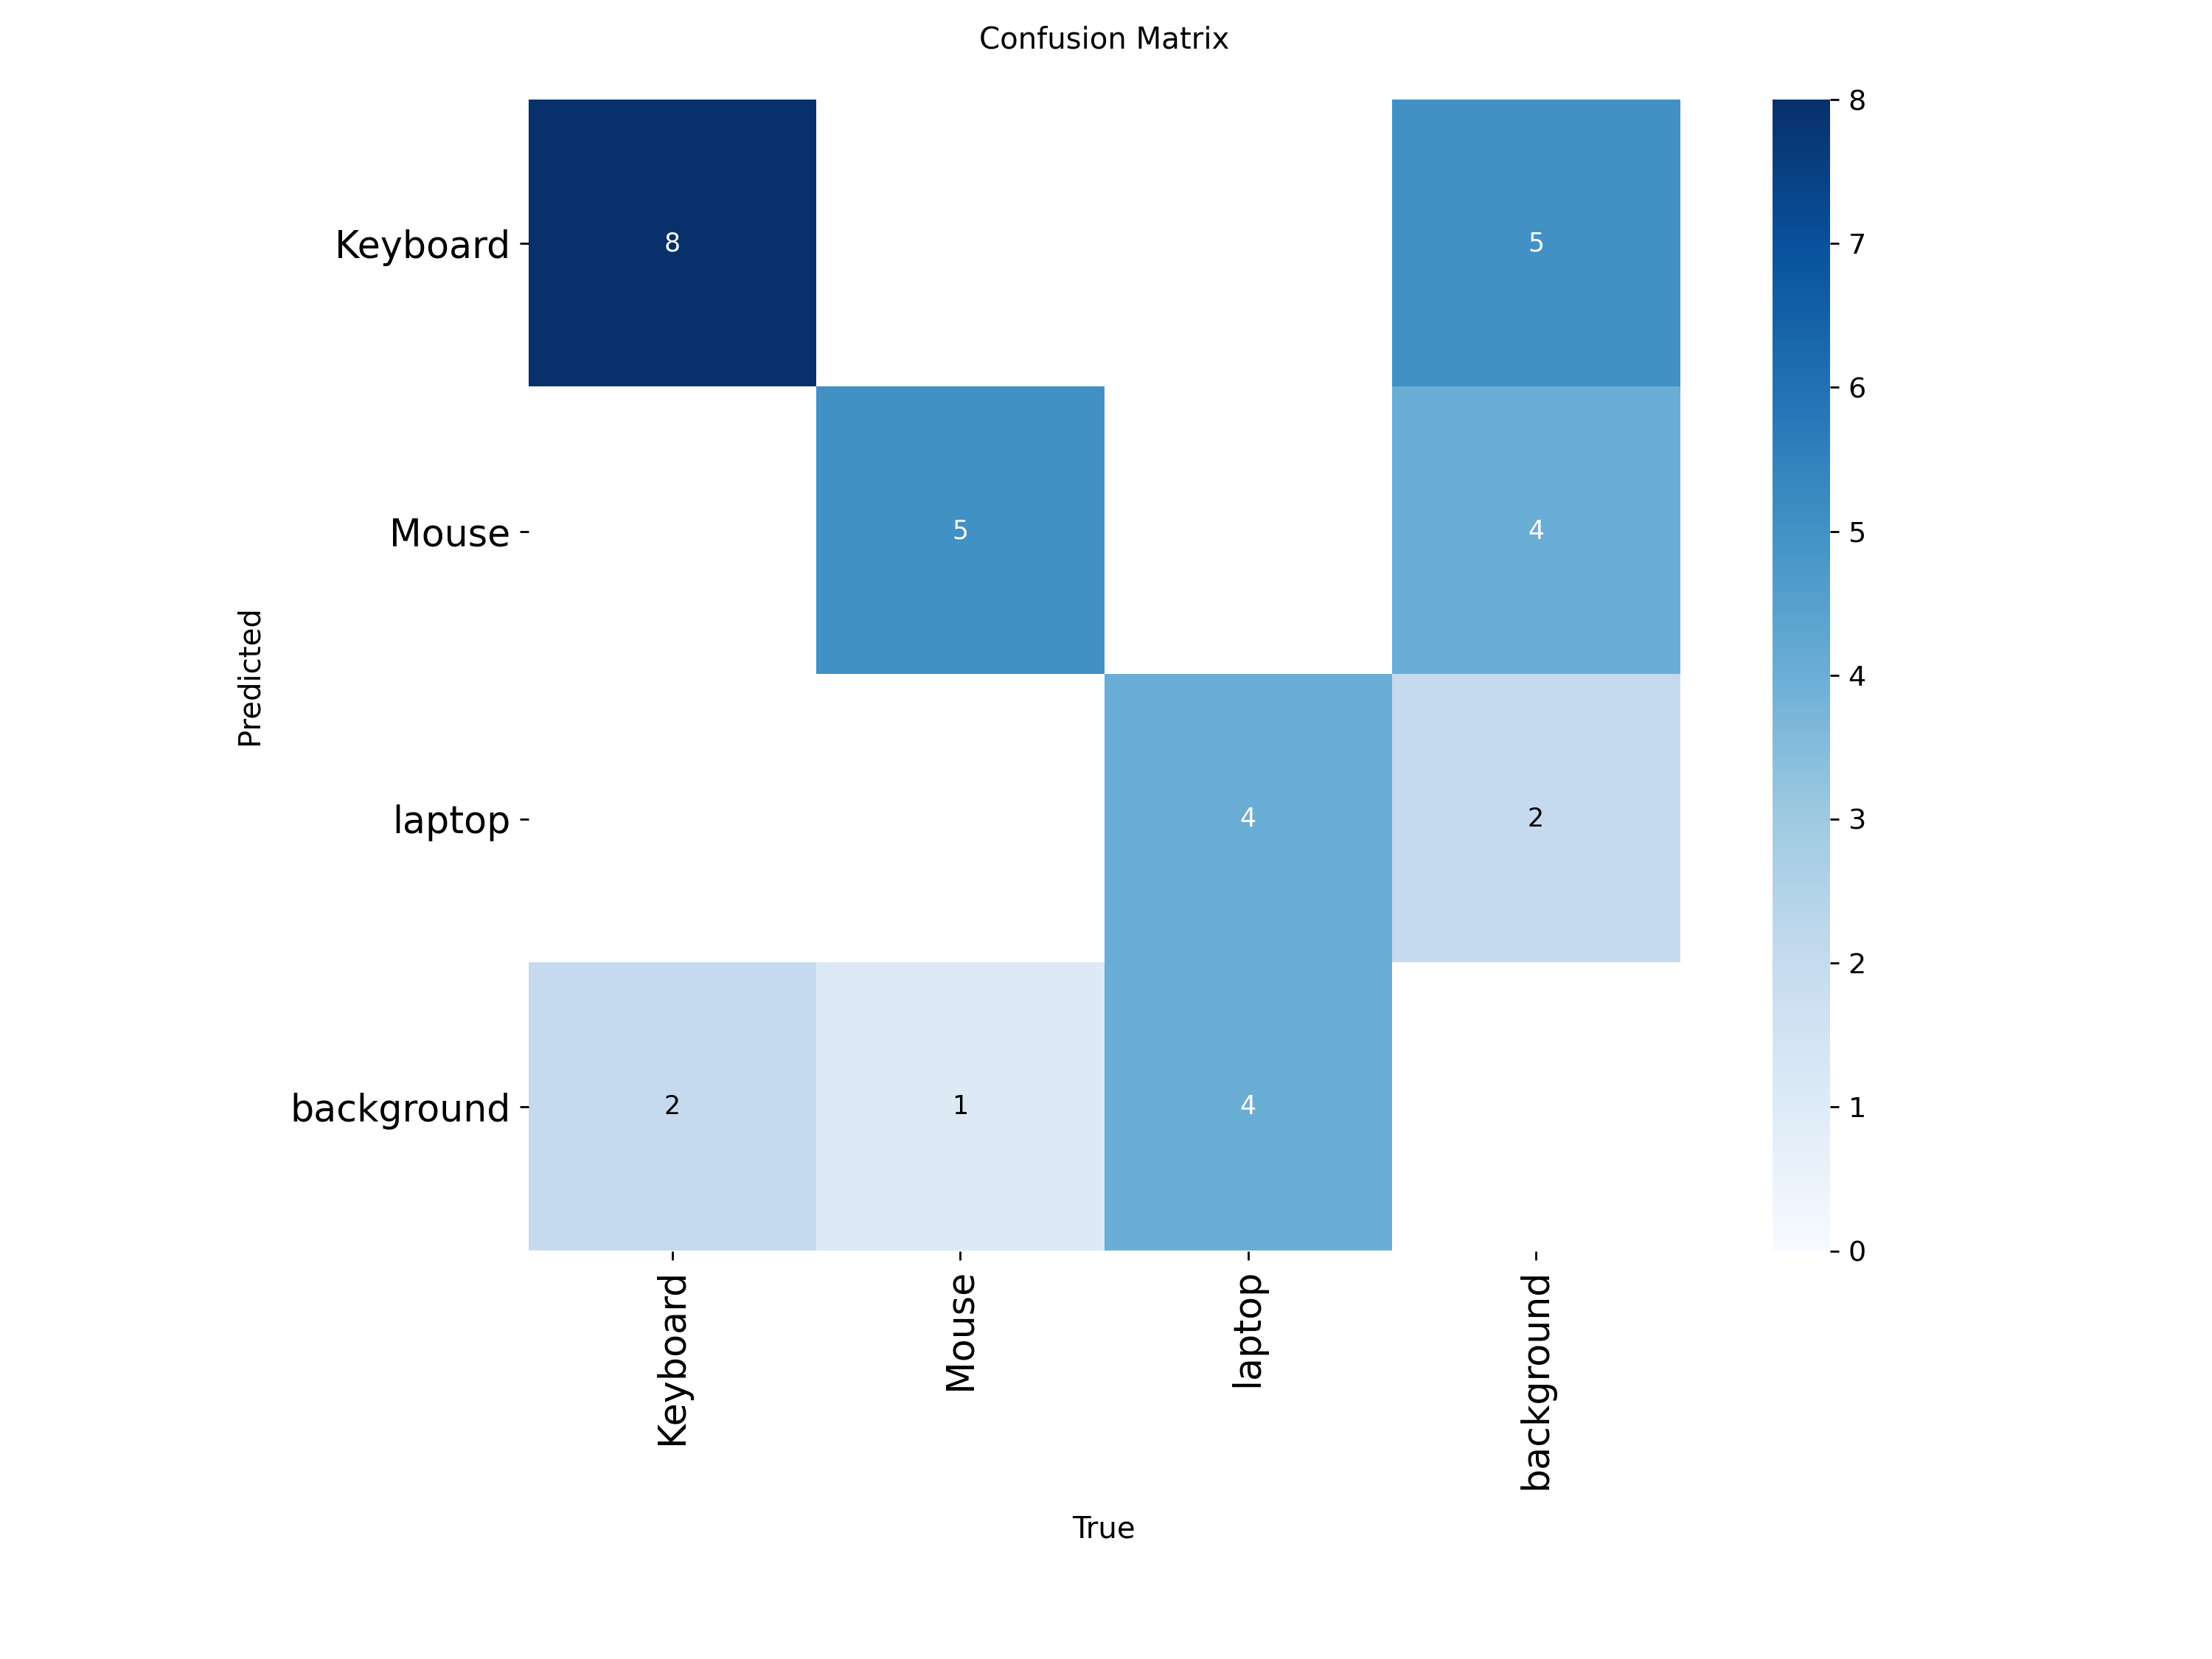

In [49]:
#Confusion MAtrix
display(Image(filename="/content/runs/detect/val-7/confusion_matrix.png"))

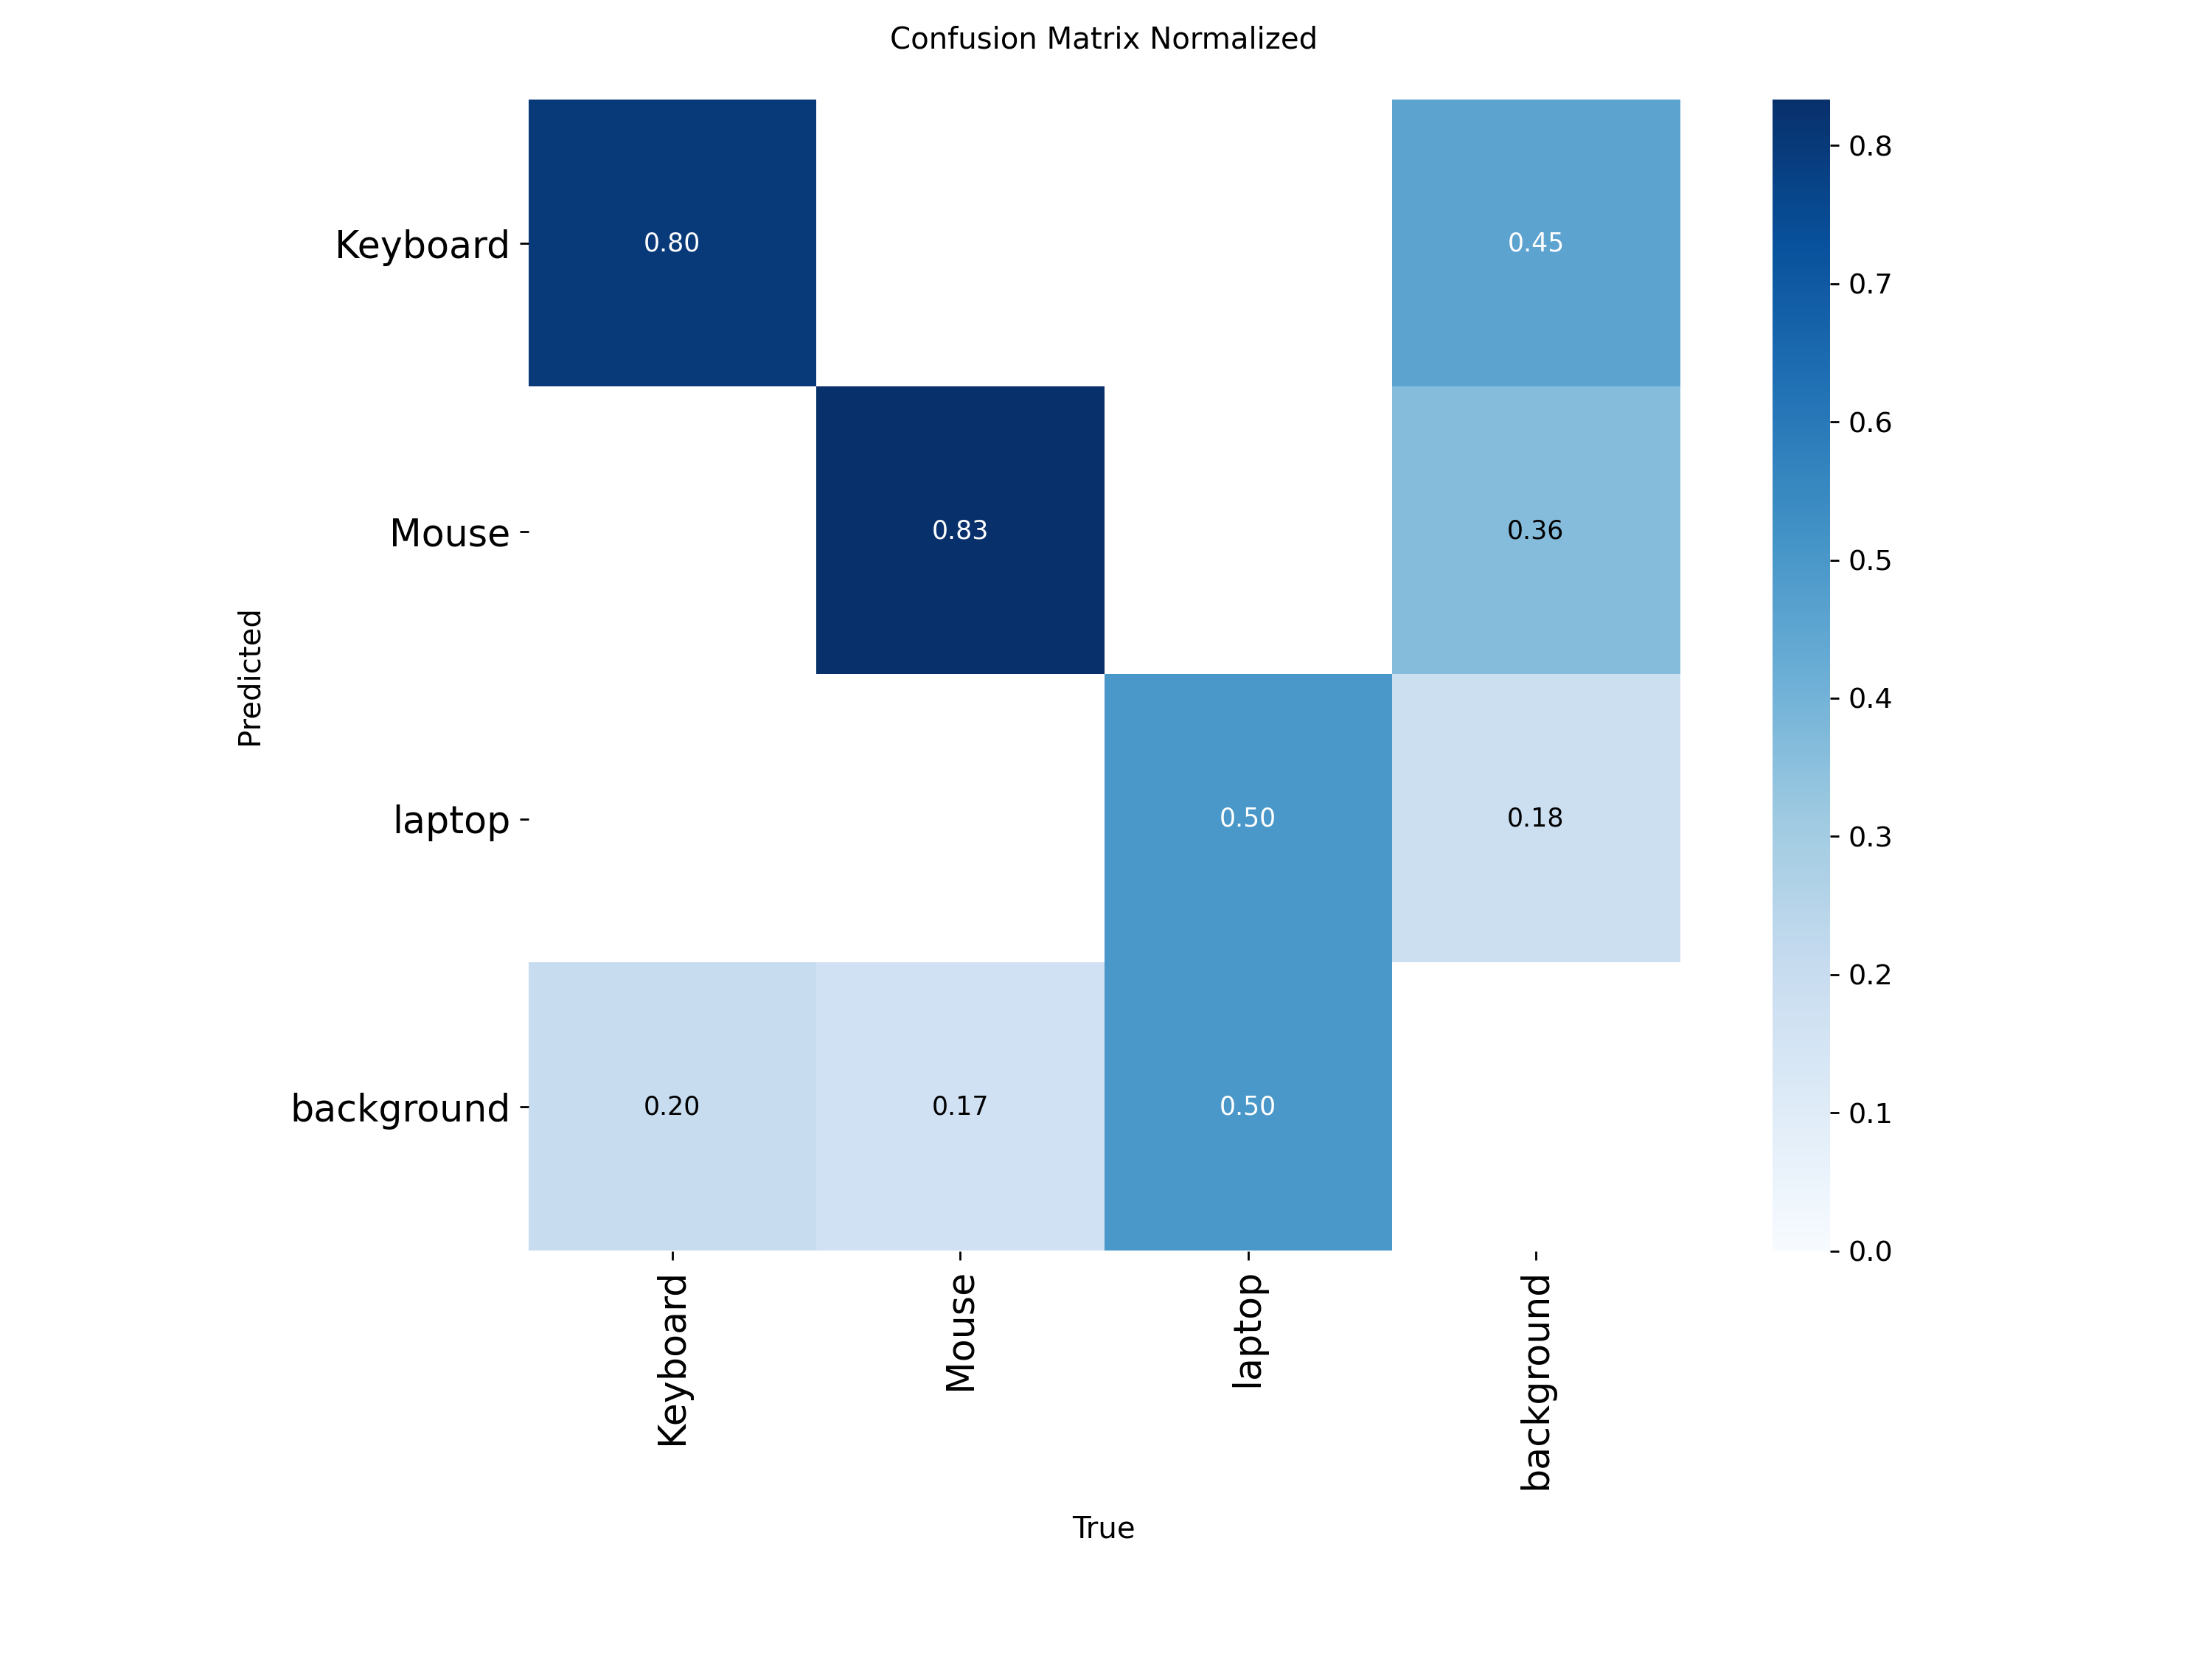

In [50]:
display(Image(filename="/content/runs/detect/val-7/confusion_matrix_normalized.png"))

#Making Our Third Model

In [52]:
model_2n = YOLO("yolov10n.pt")

In [54]:
model_2n.train(data="/content/Keyboard_mouse and Laptop Detection/data.yaml",epochs=40)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Keyboard_mouse and Laptop Detection/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=None, opset=N

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7badf61ec130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

#mAP Graph

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("runs/detect/train/results.csv")

plt.plot(results["epoch"], results["metrics/mAP50(B)"], label="mAP50")
plt.plot(results["epoch"], results["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("mAP vs Epoch")
plt.legend()
plt.show()

In [55]:
model_2nb=YOLO("/content/runs/detect/train-6/weights/best.pt")

#Evaluating our third Model

In [56]:
results_2nb = model_2nb.val(
    data="/content/Keyboard_mouse and Laptop Detection/data.yaml",
    split="test"
)


Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 99 layers, 2,265,753 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 893.0±339.2 MB/s, size: 42.5 KB)
val: Scanning /content/Keyboard_mouse and Laptop Detection/test/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.0it/s 0.3s
                   all         10         24      0.884      0.733      0.845      0.457
              Keyboard          6         10      0.887      0.783      0.806      0.418
                 Mouse          6          6      0.943      0.833      0.955      0.627
                laptop          2          8      0.822      0.583      0.774      0.327
Speed: 0.8ms preprocess, 5.8ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /content/runs/d

In [58]:
print("Precision:", results_2nb.box.mp)
print("Recall:", results_2nb.box.mr)
print("mAP50:", results_2nb.box.map50)
print("mAP50-95:", results_2nb.box.map)

Precision: 0.8839658614901763
Recall: 0.7334300365600092
mAP50: 0.8450010827060007
mAP50-95: 0.45716839736823106


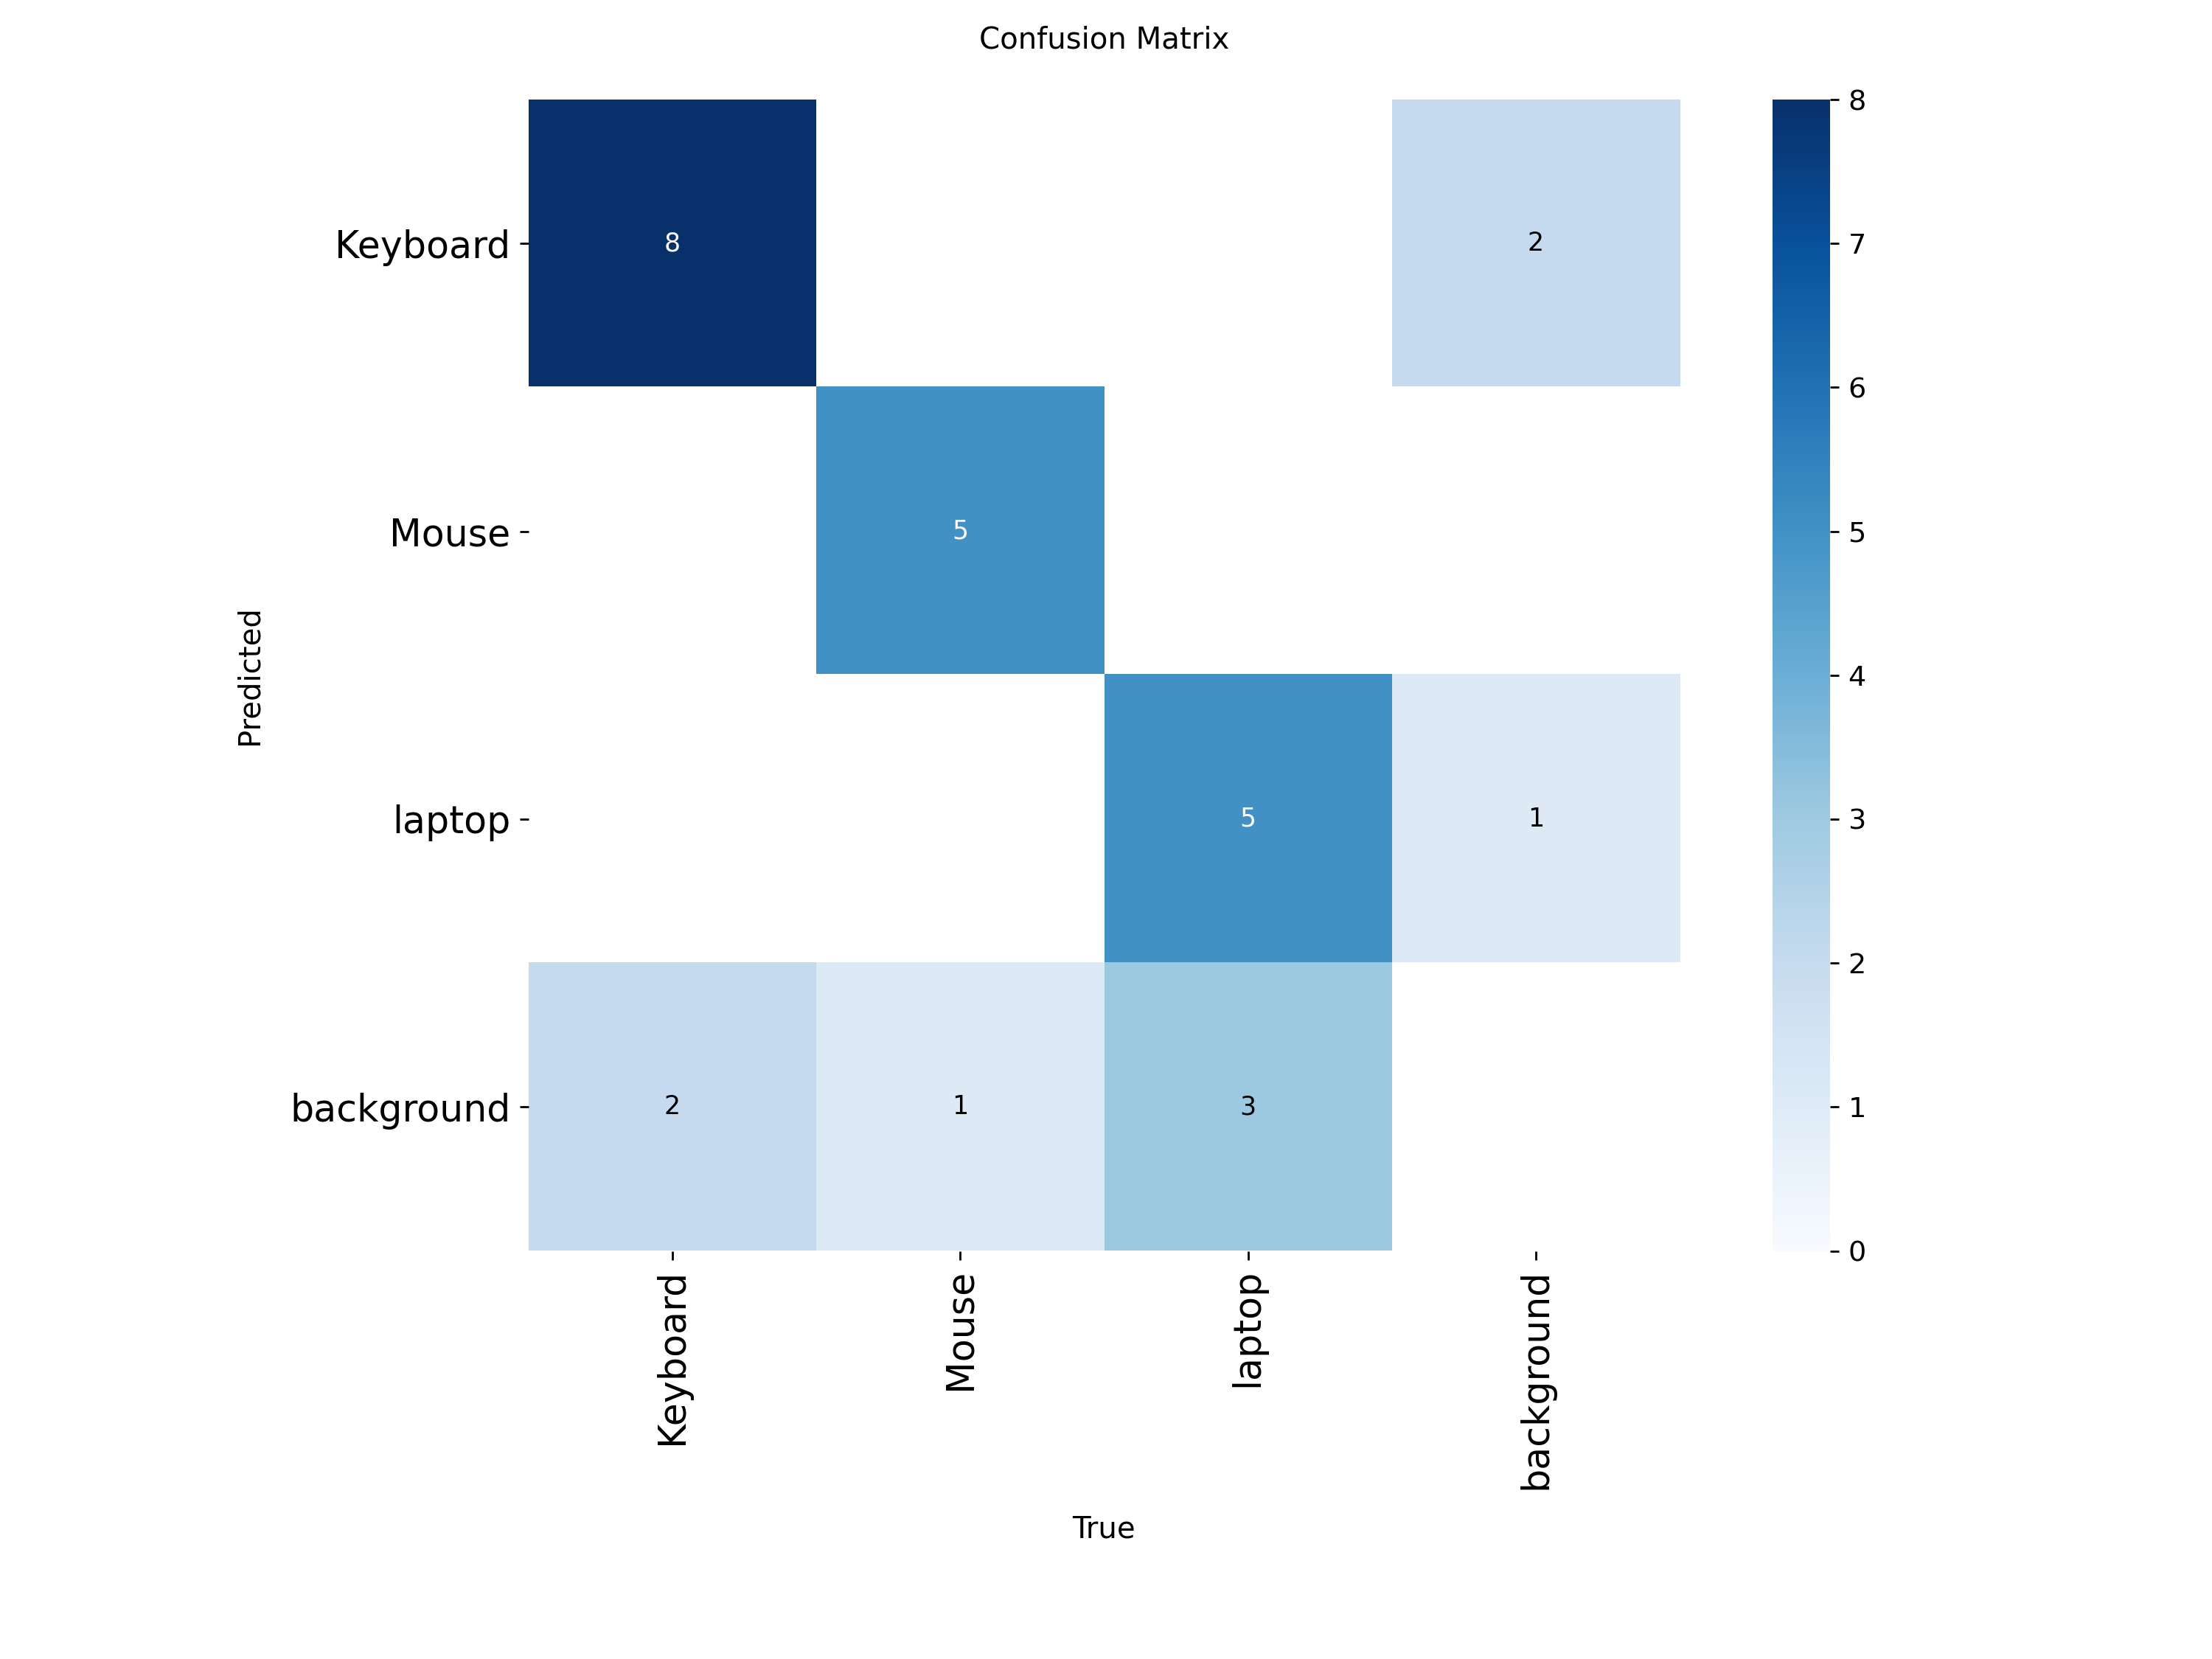

In [59]:
#Confusion Matrix
display(Image(filename="/content/runs/detect/val-8/confusion_matrix.png"))

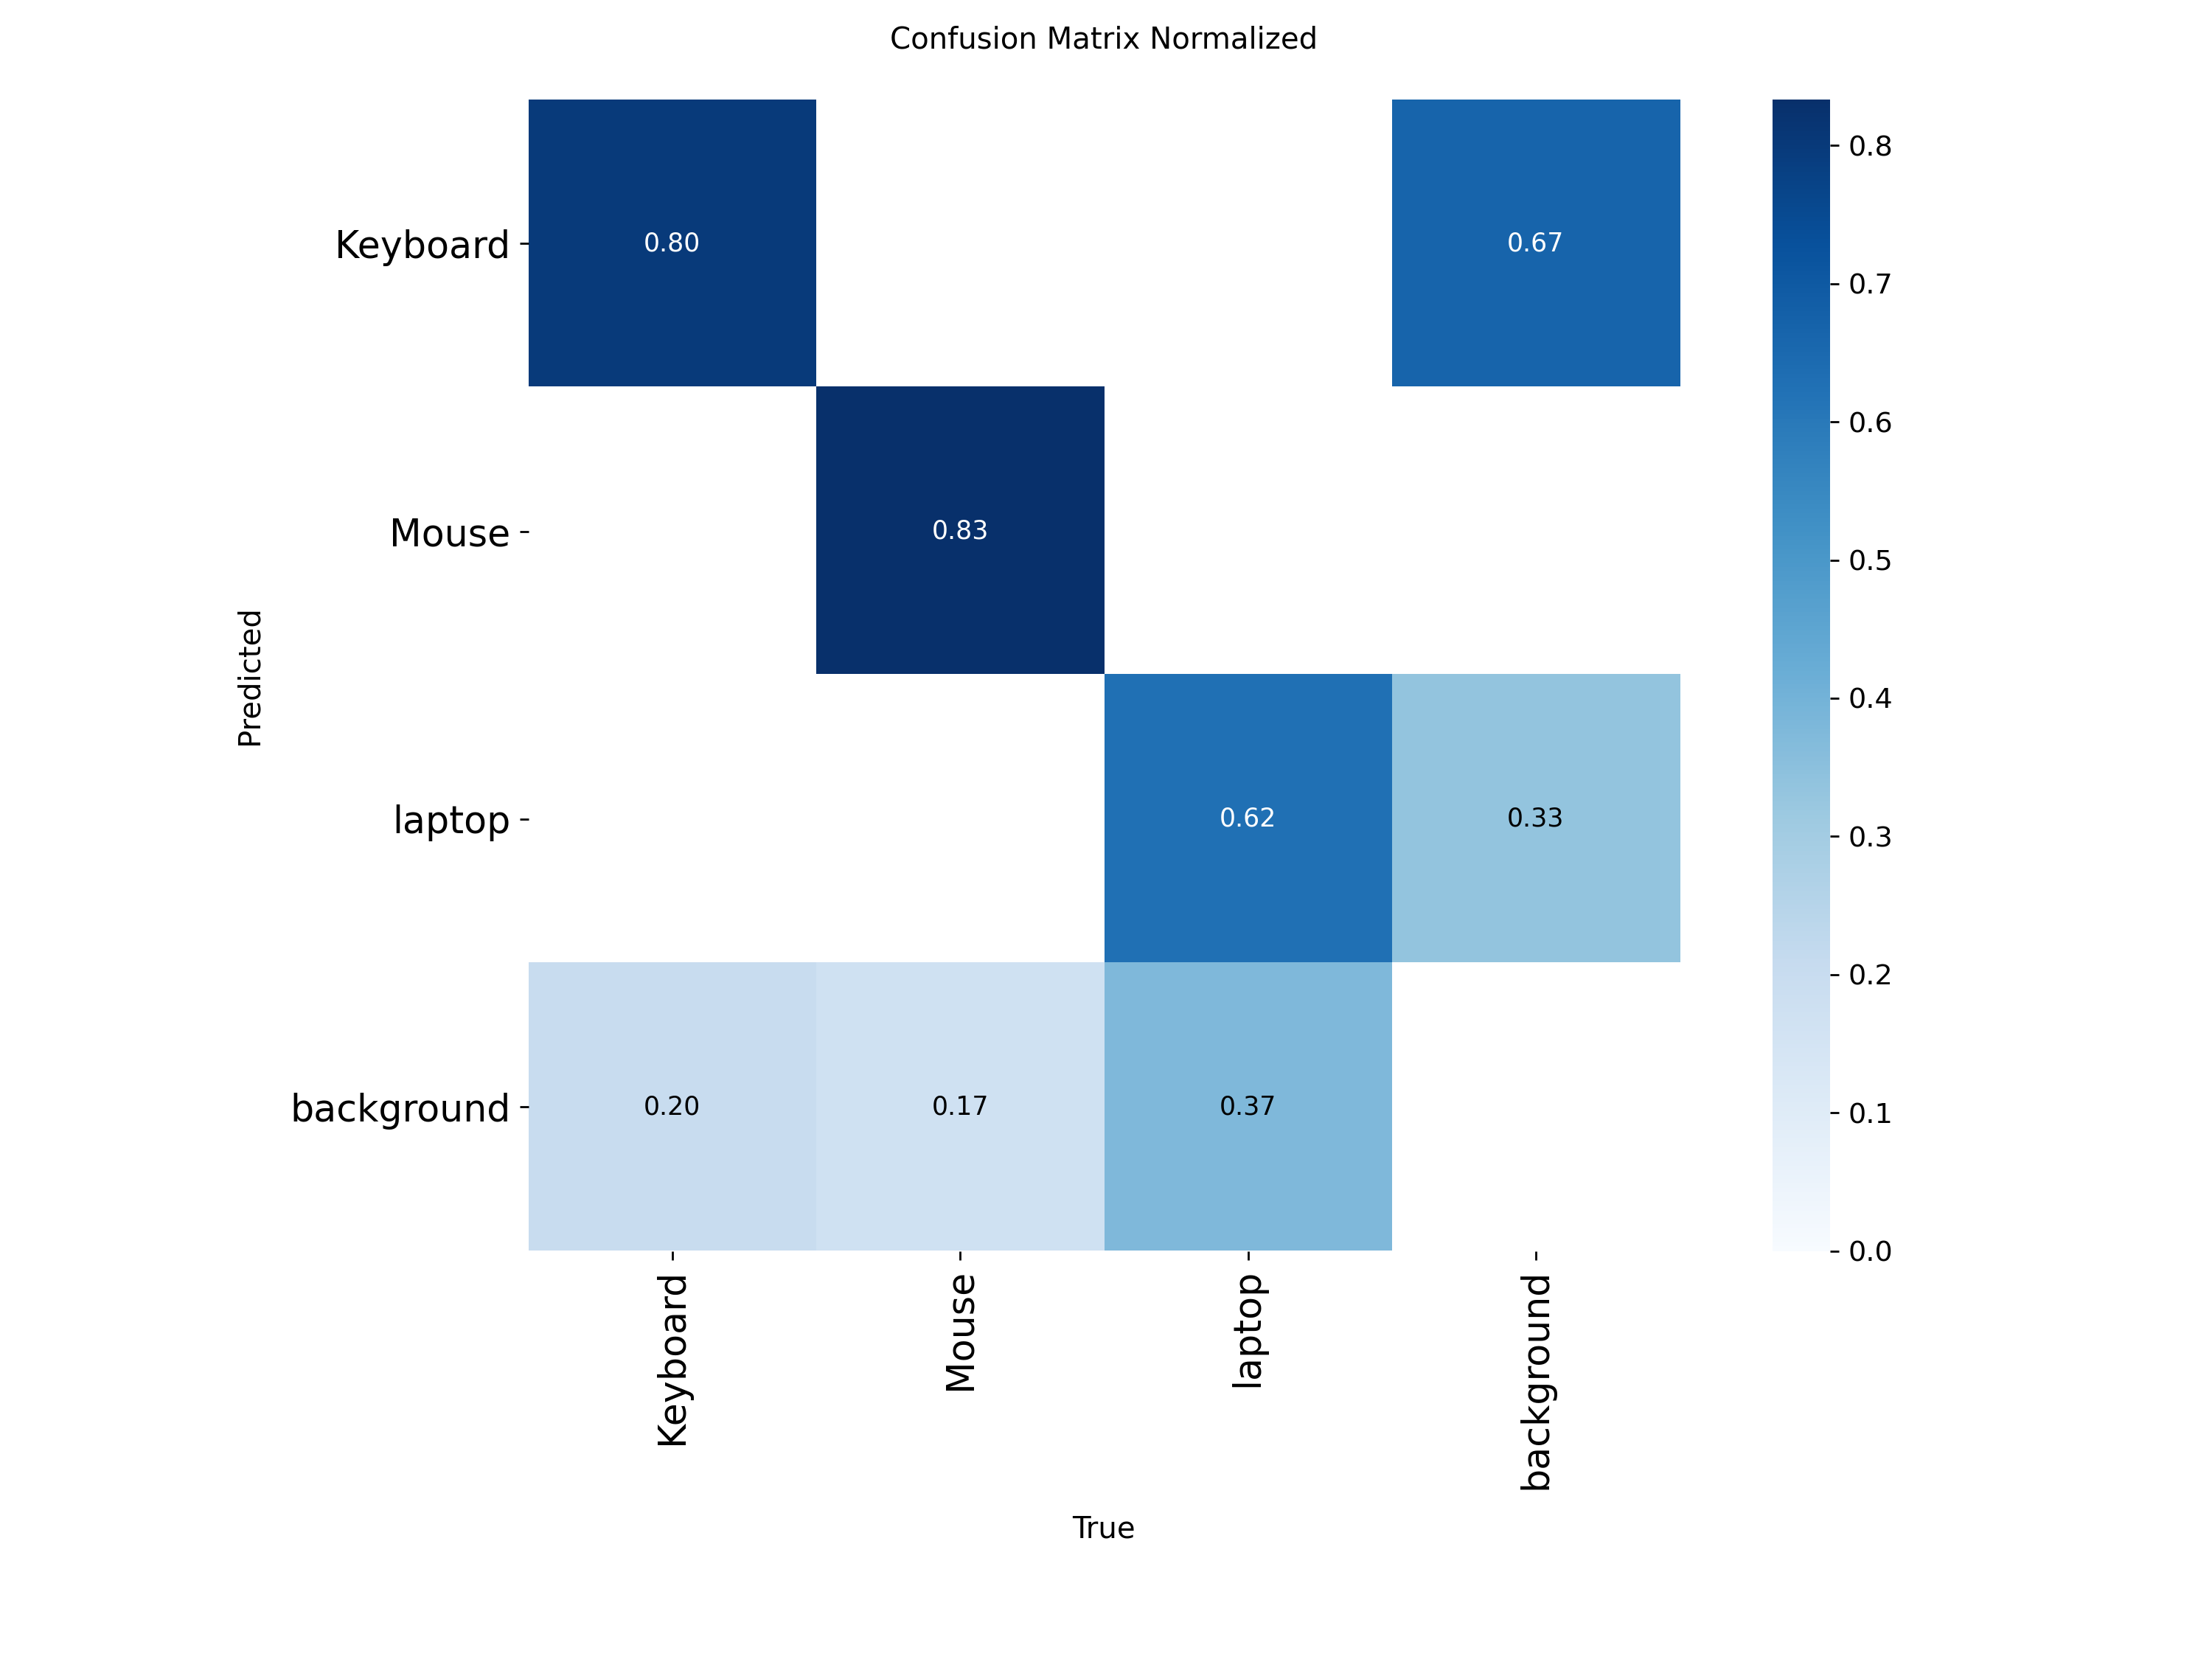

In [60]:
display(Image(filename="/content/runs/detect/val-8/confusion_matrix_normalized.png"))